## DATA PRE-PROCESSING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
# Create Dataframe
df = pd.read_csv("./EasyVisa.csv")
# Print shape of dataset
print(df.shape)

(25480, 12)


## DATA CLEANING

In [2]:
features_with_na=[features for features in df.columns if df[features].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5), '% missing values')
features_with_na

[]

* There are no null values in the dataset

In [3]:
df.duplicated().sum()

np.int64(0)

* No Duplicates in the dataset

In [4]:
df.drop('case_id', inplace=True, axis=1)

# Feature Engineering

In [5]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [6]:
# importing date class from datetime module
from datetime import date
  
# creating the date object of today's date
todays_date = date.today()
current_year= todays_date.year

df['company_age'] = current_year-df['yr_of_estab']
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,21


In [7]:
df.drop('yr_of_estab', inplace=True, axis=1) # Using age instead of year established gives the model a more meaningful and learnable feature (how
# old the entity is), and it can also reduce issues caused by skewed or poorly scaled year values.

In [8]:
num_features = df.select_dtypes(include=['number']).columns.tolist()
print('Num of Numerical Features :', len(num_features))
cat_features = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
print('Num of Categorical Features :', len(cat_features))

Num of Numerical Features : 3
Num of Categorical Features : 8


In [9]:
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]
print('Num of Discrete Features :',len(discrete_features))
continuous_features=[feature for feature in num_features if feature not in discrete_features]
print('Num of Continuous Features :',len(continuous_features))

Num of Discrete Features : 0
Num of Continuous Features : 3


In [10]:
X = df.drop('case_status', axis=1)
y = df['case_status']

In [11]:
# If the target column has Denied it is encoded as 1 others as 0
y= np.where(y=='Denied', 1,0)
y

array([1, 0, 1, ..., 0, 0, 0], shape=(25480,))

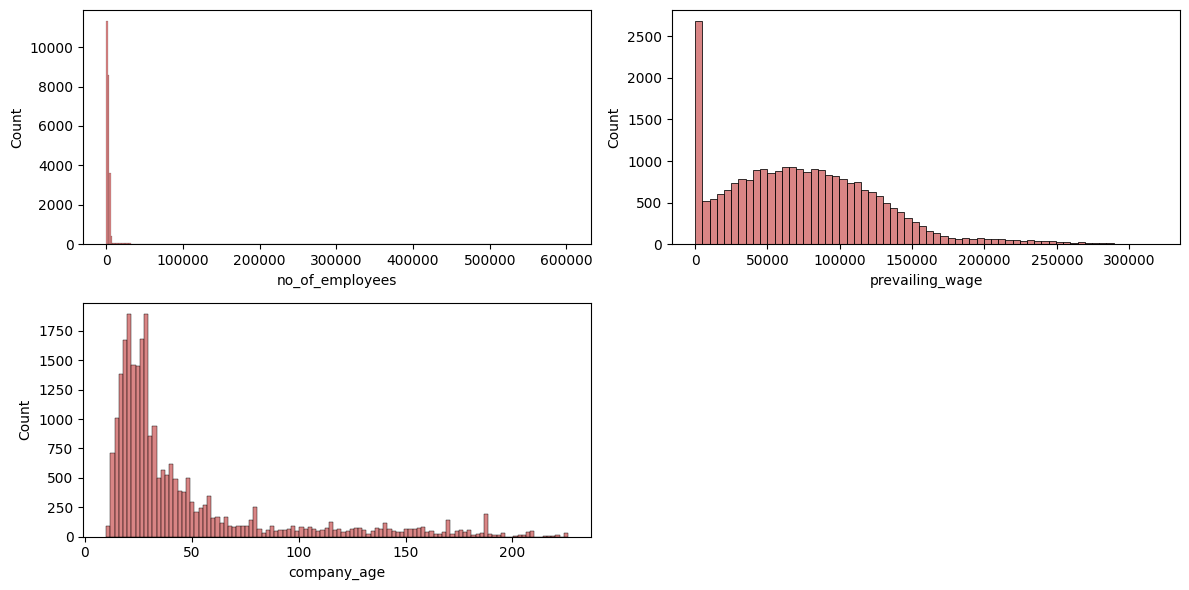

In [12]:
# distribution of data before scaling
plt.figure(figsize=(12, 6))
for i, col in enumerate(['no_of_employees','prevailing_wage','company_age']):
    plt.subplot(2, 2, i+1)
    sns.histplot(x=X[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

## Skewness refers to a distortion or asymmetry that deviates from the symmetrical bell curve, or normal distribution, in a set of data. If the curve is shifted to the left or to the right, it is said to be skewed. Skewness can be quantified as a representation of the extent to which a given distribution varies from a normal distribution. A normal distribution has a skew of zero

In [13]:
# Check Skewness
X[continuous_features].skew(axis=0, skipna=True)

no_of_employees    12.265260
prevailing_wage     0.755776
company_age         2.037301
dtype: float64

## Power transforms are a family of parametric, monotonic transformations that are applied to make data more Gaussian-like. This is useful for modeling issues related to heteroscedasticity (non-constant variance), or other situations where normality is desired.

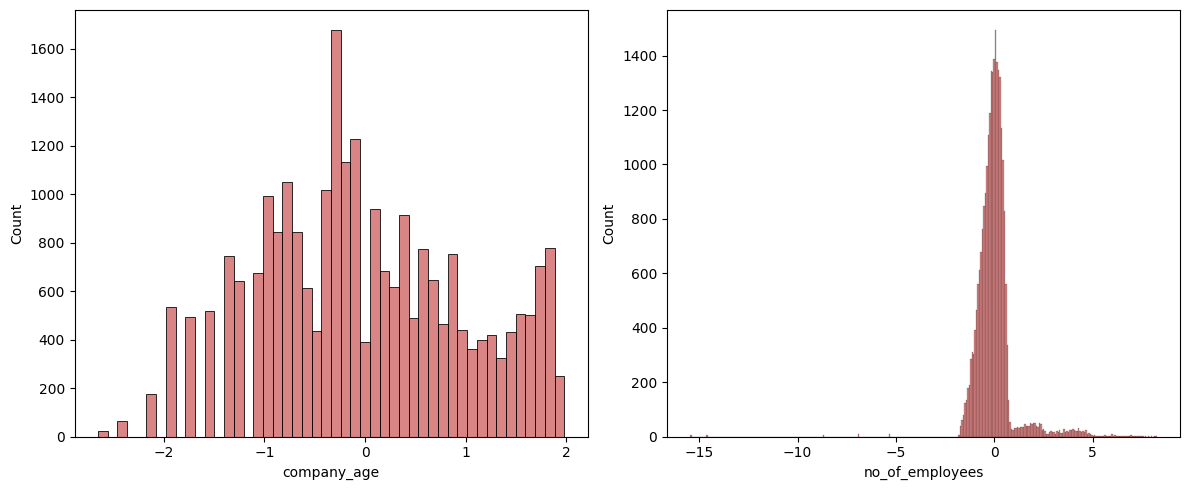

In [14]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
transform_features = ['company_age', 'no_of_employees']
X_copy = pt.fit_transform(X[transform_features])
X_copy = pd.DataFrame(X_copy, columns=transform_features)
plt.figure(figsize=(12, 5))
for i, col in enumerate(transform_features):
    plt.subplot(1, 2, i+1)
    sns.histplot(x=X_copy[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

In [15]:
X_copy.skew(axis=0, skipna=True)

company_age        0.120823
no_of_employees    0.399339
dtype: float64

## NOW WE KNOW HOW TO SOLVE THE SKEWNESS(via power transform) AND THE OUTLIERS CAN BE HANDLED VIA SCALING

In [16]:
for feature in cat_features:
    print(feature,':', df[feature].nunique())

continent : 6
education_of_employee : 4
has_job_experience : 2
requires_job_training : 2
region_of_employment : 5
unit_of_wage : 4
full_time_position : 2
case_status : 2


# Quick Comparison

| Feature                  | Label Encoding   | Ordinal Encoding    | One-Hot Encoding        |
| ------------------------ | ---------------- | ------------------- | ----------------------- |
| Output                   | Single integer   | Single integer      | Multiple binary columns |
| Assumes order?           | Yes (implicitly) | Yes (intentionally) | No                      |
| Memory efficient         | Yes              | Yes                 | No                      |
| Good for nominal data    | Sometimes        | No                  | Yes                     |
| Good for ordered data    | No               | Yes                 | Not ideal               |
| Risk of misleading model | High             | Low (if ordered)    | Low                     |

---

In [17]:
or_columns = ['has_job_experience','requires_job_training','full_time_position','education_of_employee']
oh_columns = ['continent','unit_of_wage','region_of_employment']
transform_columns= ['no_of_employees','company_age']
for col in or_columns:
    print(col)
    print(df[col].unique())
    print()

has_job_experience
<StringArray>
['N', 'Y']
Length: 2, dtype: str

requires_job_training
<StringArray>
['N', 'Y']
Length: 2, dtype: str

full_time_position
<StringArray>
['Y', 'N']
Length: 2, dtype: str

education_of_employee
<StringArray>
['High School', 'Master's', 'Bachelor's', 'Doctorate']
Length: 4, dtype: str



In [18]:
ordinal_categories = [
    ['N', 'Y'],                                   # has_job_experience
    ['N', 'Y'],                                   # requires_job_training
    ['N', 'Y'],                                   # full_time_position
    ['High School', "Bachelor's", "Master's", 'Doctorate'] # specifies the order right has more importance so order matters here
]

from sklearn.preprocessing import OneHotEncoder, StandardScaler,OrdinalEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()
ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)

transform_pipe = Pipeline(steps=[
    ('transformer', PowerTransformer(method='yeo-johnson'))
])

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, oh_columns),
        ("Ordinal_Encoder", ordinal_encoder, or_columns),
        ("Transformer", transform_pipe, transform_columns),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)

In [19]:
X = preprocessor.fit_transform(X)

In [20]:
from imblearn.combine import SMOTEENN

# Resampling the minority class. The strategy can be changed as required.
smt = SMOTEENN(random_state=42,sampling_strategy='minority' )
# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X, y)

In [21]:
from sklearn.model_selection import  train_test_split
# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X_res,y_res,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((13824, 24), (3457, 24))

In [22]:

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score,roc_curve 
from xgboost import XGBClassifier

In [23]:
def evaluate_model(true, predicted):
    acc = accuracy_score(true, predicted) # Calculate Accuracy
    f1 = f1_score(true, predicted) # Calculate F1-score
    precision = precision_score(true, predicted) # Calculate Precision
    recall = recall_score(true, predicted)  # Calculate Recall
    roc_auc = roc_auc_score(true, predicted) #Calculate Roc
    return acc, f1 , precision, recall, roc_auc

In [24]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
     "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(),
     "Support Vector Classifier": SVC(),
    "AdaBoost Classifier": AdaBoostClassifier()

}

In [25]:
# Create a function which can evaluate models and return a report 
def evaluate_models(X, y, models):
    '''
    This function takes in X and y and models dictionary as input
    It splits the data into Train Test split
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost
    '''
    # separate dataset into train and test
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    
    models_list = []
    accuracy_list = []
    auc= []
    
    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train) # Train model

        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Training set performance
        model_train_accuracy, model_train_f1,model_train_precision,\
        model_train_recall,model_train_rocauc_score=evaluate_model(y_train ,y_train_pred)


        # Test set performance
        model_test_accuracy,model_test_f1,model_test_precision,\
        model_test_recall,model_test_rocauc_score=evaluate_model(y_test, y_test_pred)

        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])

        print('Model performance for Training set')
        print("- Accuracy: {:.4f}".format(model_train_accuracy))
        print('- F1 score: {:.4f}'.format(model_train_f1)) 
        print('- Precision: {:.4f}'.format(model_train_precision))
        print('- Recall: {:.4f}'.format(model_train_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

        print('----------------------------------')

        print('Model performance for Test set')
        print('- Accuracy: {:.4f}'.format(model_test_accuracy))
        accuracy_list.append(model_test_accuracy)
        print('- F1 score: {:.4f}'.format(model_test_f1))
        print('- Precision: {:.4f}'.format(model_test_precision))
        print('- Recall: {:.4f}'.format(model_test_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
        auc.append(model_test_rocauc_score)
        print('='*35)
        print('\n')
        
    report=pd.DataFrame(list(zip(models_list, accuracy_list)), columns=['Model Name', 'Accuracy']).sort_values(by=['Accuracy'], ascending=False)
        
    return report

In [26]:
base_model_report =evaluate_models(X=X_res, y=y_res, models=models)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9445
- F1 score: 0.9480
- Precision: 0.9501
- Recall: 0.9459
- Roc Auc Score: 0.9443


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9219
- F1 score: 0.9273
- Precision: 0.9234
- Recall: 0.9314
- Roc Auc Score: 0.9212


Gradient Boosting
Model performance for Training set
- Accuracy: 0.8826
- F1 score: 0.8912
- Precision: 0.8907
- Recall: 0.8916
- Roc Auc Score: 0.8818
----------------------------------
Model performance for Test set
- Accuracy: 0.8866
- F1 score: 0.8939
- Precision: 0.8953
- Recall: 0.8924
- Roc Auc Score: 0.8862


Logistic Regression
Model performance for Training 

In [27]:
print(base_model_report)

                  Model Name  Accuracy
0              Random Forest  0.944461
4     K-Neighbors Classifier  0.939832
5              XGBClassifier  0.927394
1              Decision Tree  0.921898
2          Gradient Boosting  0.886607
6  Support Vector Classifier  0.885161
7        AdaBoost Classifier  0.863465
3        Logistic Regression  0.860573


In [28]:
dt_params = {
    "max_depth": range(3, 15, 2),
    "min_samples_split": range(2, 10, 2),
    "min_samples_leaf": range(1, 5),
    "criterion": ["gini", "entropy"]
}
xgboost_params = {
    'max_depth':range(3,10,2),
    'min_child_weight':range(1,6,2)
}

rf_params = {
    "max_depth": [10, 12, None, 15, 20],
    "max_features": ['sqrt', 'log2', None],
    "n_estimators": [10, 50, 100, 200]
}

knn_params = {
    "algorithm": ['auto', 'ball_tree', 'kd_tree','brute'],
    "weights": ['uniform', 'distance'],
    "n_neighbors": [3, 4, 5, 7, 9],
}

In [29]:
# Models list for Hyperparameter tuning
randomcv_models = [
    ('XGBoost', XGBClassifier(), xgboost_params),
    ('DT', DecisionTreeClassifier(), dt_params),
    ("RF", RandomForestClassifier(), rf_params),
    ("KNN", KNeighborsClassifier(), knn_params)
]

In [30]:

from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=3,
                                   verbose=2, 
                                   n_jobs=-1)
    random.fit(X_res, y_res)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Fitting 3 folds for each of 40 candidates, totalling 120 fits
---------------- Best Params for XGBoost -------------------
{'min_child_weight': 1, 'max_depth': 9}
---------------- Best Params for DT -------------------
{'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 13, 'criterion': 'gini'}
---------------- Best Params for RF -------------------
{'n_estimators': 200, 'max_features': 'sqrt', 'max_depth': None}
---------------- Best Params for KNN -------------------
{'weights': 'distance', 'n_neighbors': 4, 'algorithm': 'auto'}


In [31]:
from sklearn.metrics import roc_auc_score,roc_curve
best_models = {
    "Random Forest Classifier": RandomForestClassifier(**model_param['RF']),
    "KNeighborsClassifier": KNeighborsClassifier(**model_param['KNN']),
    "Decision Tree": DecisionTreeClassifier(**model_param["DT"]),
    "XGBClassifier": XGBClassifier(**model_param['XGBoost'],n_jobs=-1),
}
tuned_report =evaluate_models(X=X_res, y=y_res, models=best_models)

Random Forest Classifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9453
- F1 score: 0.9488
- Precision: 0.9506
- Recall: 0.9470
- Roc Auc Score: 0.9452


KNeighborsClassifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9685
- F1 score: 0.9710
- Precision: 0.9565
- Recall: 0.9859
- Roc Auc Score: 0.9671


Decision Tree
Model performance for Training set
- Accuracy: 0.9555
- F1 score: 0.9589
- Precision: 0.9545
- Recall: 0.9634
- Roc Auc Score: 0.9548
----------------------------------
Model performance for Test set
- Accuracy: 0.9016
- F1 score: 0.9090
- Precision: 0.8999
- Recall: 0.9184
- Roc Auc Score: 0.9004


XGBClassifier
Model performance for T

In [32]:
tuned_report

,Model Name,Accuracy
1,KNeighborsClassifier,0.968470
0,Random Forest Classifier,0.945328
3,XGBClassifier,0.942436
2,Decision Tree,0.901649


In [33]:
best_model = KNeighborsClassifier(**model_param['KNN'])
best_model = best_model.fit(X_train,y_train)
y_pred = best_model.predict(X_test)
score = accuracy_score(y_test,y_pred)
cr = classification_report(y_test,y_pred)

print("FINAL MODEL 'KNN'")
print ("Accuracy Score value: {:.4f}".format(score))
print (cr)

FINAL MODEL 'KNN'
Accuracy Score value: 0.9685
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      1607
           1       0.96      0.99      0.97      1850

    accuracy                           0.97      3457
   macro avg       0.97      0.97      0.97      3457
weighted avg       0.97      0.97      0.97      3457



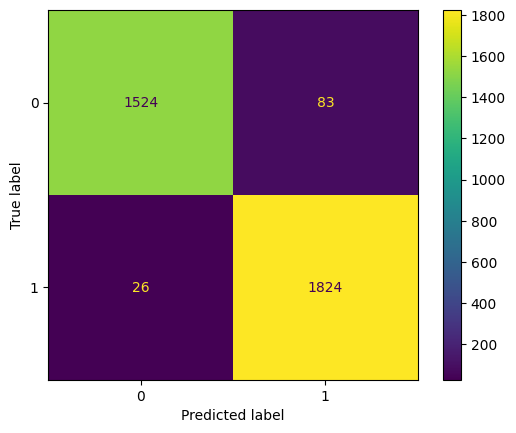

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)

# Best Model is K-Nearest Neighbor(KNN) with Accuracy 96.85%